# 01 - Data analysis

Daily OHLCV for every ticker that was an S&P 500 member between 2006 and 2025 (point-in-time
membership from `fja05680/sp500`, pinned commit), downloaded from Yahoo Finance and cached as a
fixed parquet snapshot. This notebook re-runs the data stage (`src.data.build_panel`) and inspects
data quality, cleaning, and universe coverage.

**Known limitation (survivorship):** Yahoo only serves currently listed symbols, so most delisted
former members are missing. The point-in-time mask prevents trading a stock before it joined the
index, but it cannot add back companies that later failed or were acquired.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import Image, display
T, F, D = ROOT / "results/tables", ROOT / "results/figures", ROOT / "data/processed"
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 200)
from src.config import figure_relpath, table_relpath
def table(name, **kw):
    return pd.read_csv(T / table_relpath(name), **kw)
def fig(key, width=1100):
    display(Image(filename=str(F / figure_relpath(key)), width=width))

In [2]:
from src.config import load_config
from src.data import build_panel
from src.preprocessing import build_universe, daily_returns
cfg = load_config()
panel = build_panel(cfg)
adj = panel["wide"]["adj_close"]
rets = daily_returns(adj)
universe = build_universe(panel["wide"], panel["membership"], cfg["universe"])
print(adj.shape, adj.index.min().date(), adj.index.max().date())

(5031, 648) 2006-01-03 2025-12-31


## Data-quality checks (raw vs. cleaned)

In [3]:
pd.DataFrame({"raw": pd.Series(panel["quality_raw"]), "clean": pd.Series(panel["quality_clean"])})

,raw,clean
rows,2877869,2877771
tickers,648,648
dates,5031,5031
first_date,2006-01-03,2006-01-03
last_date,2025-12-31,2025-12-31
duplicate_rows,0,0
missing_adj_close,0,0
missing_ohlc,0,0
missing_volume,0,0
zero_volume,10447,10447


In [4]:
pd.Series(panel["cleaning_actions"], name="count").to_frame()

,count
duplicates_dropped,0
non_positive_prices_set_nan,0
negative_volume_set_nan,0
extreme_return_days_set_nan,98
rows_after_cleaning,2877771


* No duplicates, missing values, non-positive prices or inconsistent OHLC rows were found in the raw snapshot.
* Zero-volume days are kept in the panel but excluded from the tradable universe on that day.
* Returns beyond ±75% in one day are treated as bad prints (prices set to NaN); see the count above.
* Dividend/split adjustment events are counted from changes in the `adj_close / close` ratio;
  returns use `adj_close` only.

## Survivorship: how much of the index is covered?

In [5]:
mem = pd.read_csv(ROOT / "data/raw/sp500_membership.csv", parse_dates=["date"]).set_index("date")["tickers"]
members_total = mem.str.split(",").str.len().reindex(adj.index, method="ffill")
with_data = (panel["membership"] & adj.notna()).sum(axis=1)
cov = pd.DataFrame({"members": members_total, "members_with_data": with_data, "tradable": universe.sum(axis=1)})
cov["coverage"] = cov["members_with_data"] / cov["members"]
cov.groupby(cov.index.year).mean().round(3)

,members,members_with_data,tradable,coverage
date,,,,
2006,496.9960,277.2510,0.0000,0.5580
2007,496.9880,289.2630,281.6410,0.5820
2008,497.3950,303.0200,294.5450,0.6090
2009,498.7700,315.1980,308.6190,0.6320
2010,498.1630,326.3890,320.9290,0.6550
2011,496.9920,330.0240,326.0280,0.6640
2012,496.9680,340.5640,335.5640,0.6850
2013,496.9880,351.1310,347.3650,0.7070
2014,498.1510,357.2300,354.0990,0.7170


Coverage of the historical index rises from roughly 55% in 2006 to about 97% in 2025. The early
train period therefore over-represents companies that survived to 2026, which typically biases
long-horizon returns upward and may distort factor behaviour (e.g. fewer failed high-volatility
stocks on the short side). Results should be read with this in mind.

## Return alignment spot-check

In [6]:
t = "AAPL"
s = adj[t].dropna().iloc[1000:1004]
pd.DataFrame({"adj_close": s, "return(t)": rets[t].loc[s.index],
              "check": s / s.shift(1) - 1})

,adj_close,return(t),check
date,,,
2009-12-22,5.9927,0.0107,NaN
2009-12-23,6.0447,0.0087,0.0087
2009-12-24,6.2523,0.0343,0.0343
2009-12-28,6.3292,0.0123,0.0123


## Pooled daily-return distribution (tradable universe)

In [7]:
rets.where(universe).stack().describe(percentiles=[.001, .01, .5, .99, .999])

count   1845511.0000
mean          0.0005
std           0.0221
min          -0.6079
0.1%         -0.1376
1%           -0.0608
50%           0.0007
99%           0.0617
99.9%         0.1450
max           0.7463
dtype: float64

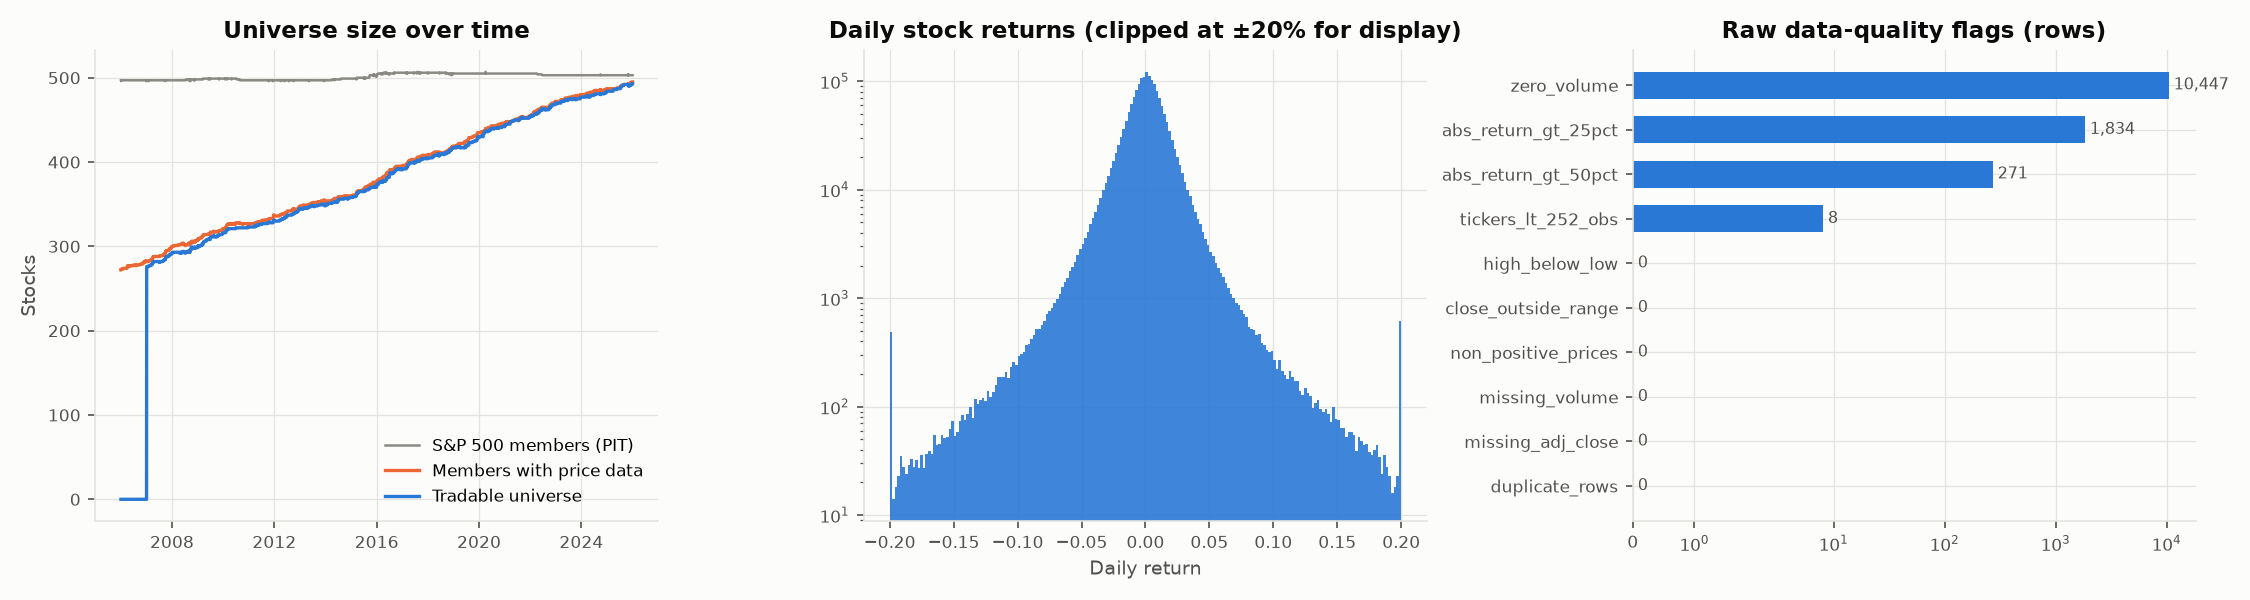

In [8]:
fig("data_quality")